In [5]:
import numpy as np
import pandas as pd
from scipy import optimize
from pandas import DataFrame as df
import matplotlib.pyplot as plt
import analysis_pca
from sklearn import linear_model

Ts = 1000
data_path = r'C:\Users\IBS\Desktop\python_code_N2'
save_path = r'C:\Users\IBS\Desktop\figures'

## Load the MF and PC linear model data (single parameter)

(116, 501)

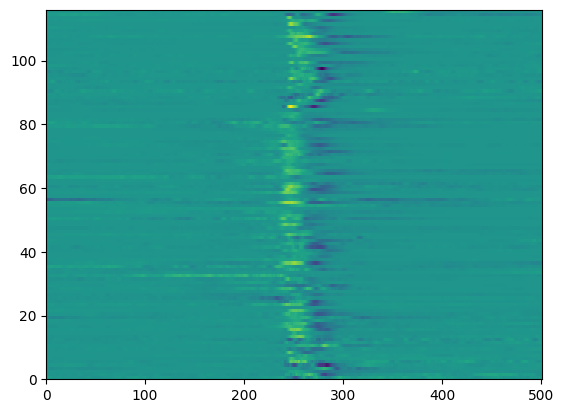

In [6]:
# Path to your Excel file
SOURCE_DATA_SF3 = 'SupplementaryFigure3.xlsx'

# Read specific sheet and ranges
mf = pd.read_excel(SOURCE_DATA_SF3, sheet_name='Figure S3b,c,d,f', usecols='A:HY', skiprows=2, nrows=502)
pc = pd.read_excel(SOURCE_DATA_SF3, sheet_name='Figure S3b,c,d,f', usecols='HZ:TP', skiprows=2, nrows=502)

# rate is ssc0, drate is wv0
lm_MF = {
    'rate': mf.iloc[:, 0:116].to_numpy().T,
    'drate': mf.iloc[:, 116:232].to_numpy().T,
    'v0': mf.iloc[0, 232],
    'label': 'MF'
}

lm_PC = {
    'rate': pc.iloc[:, 0:151].to_numpy().T,
    'drate': pc.iloc[:, 151:302].to_numpy().T,
    'v0': pc.iloc[0, 302],
    'label': 'PC'
}

plt.pcolormesh(lm_MF['drate'])
lm_MF['drate'].shape

## Load the corresponding FN linear model

In [7]:
import pickle

# with open('../../models/linear_model_FN_PV_nobaseline_20250807.pkl', 'rb') as f:
#     lmrs = pickle.load(f)

with open(r'C:\Users\user\Desktop\sunwoo\ksbns\models\linear_model_FN_PV_nobaseline_20250807.pkl', 'rb') as f:
    lmrs = pickle.load(f)

len(lmrs)

8

In [8]:
# preprocessing

pFN = []
for lm in lmrs:
    pFN.append(lm.drate)

pFN = np.array(pFN)


pMF = lm_MF['drate'][:, :500]*1e3
pPC = lm_PC['drate'][:, :500]*1e3

pMPC = np.vstack((-pPC, pMF))
pMPC = pMPC.T

# pFN = np.transpose(pFN, (2, 1, 0))

# check the shape of pFN and pMPC
print(pFN.shape, pMPC.shape)

# turn pFN into a 2d array by concatenating the first two dims
pFN = np.concatenate(pFN, axis=0)

print(pFN.shape, pMPC.shape)

(8, 67, 500) (500, 267)
(536, 500) (500, 267)


In [ ]:
# betas = []
# resids = []

# for i in range(pFN.shape[0]):
#     beta, resid = optimize.nnls(pMPC, pFN[i])
#     betas.append(beta)
#     resids.append(resid)

# betas = np.array(betas)
# resids = np.array(resids)
# betas[:,:pPC.shape[0]] = -betas[:,:pPC.shape[0]]

In [63]:
from joblib import Parallel, delayed


results = Parallel(n_jobs=-1)(
    delayed(optimize.nnls)(pMPC, row) for row in pFN
)
betas = np.array([r[0] for r in results])
resids = np.array([r[1] for r in results])
betas[:,:pPC.shape[0]] *= -1

In [67]:
betas*1e-3

array([[-2.54797332, -0.        , -0.21360598, ...,  0.        ,
         0.12827375,  1.6727363 ],
       [-0.91168488, -0.        , -0.        , ...,  0.        ,
         0.08815132,  0.40786148],
       [-1.22707078, -0.        , -0.        , ...,  0.        ,
         0.        ,  0.33920467],
       ...,
       [-1.08785953, -0.        , -0.        , ...,  0.        ,
         0.        ,  0.33924157],
       [-2.38594908, -0.        , -0.        , ...,  0.        ,
         0.30411152,  0.07151177],
       [-0.26483625, -0.29775338, -0.08814165, ...,  0.        ,
         0.        ,  0.57914066]])

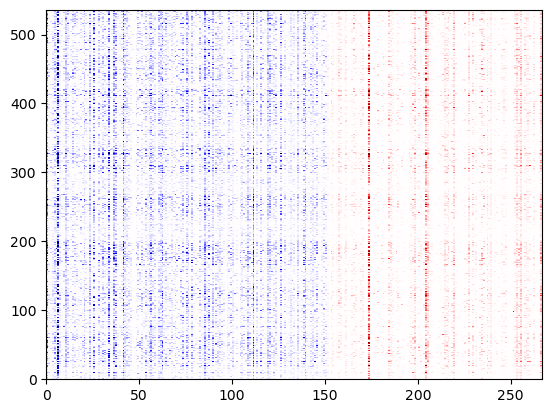

In [102]:
plt.pcolormesh(betas*1e-3, cmap='seismic');
plt.clim(-10, 10)


In [ ]:
r_s = 1 - resids**2 / (pFN.shape[1] * pFN.var(axis=1))


(0.0, 1.0)

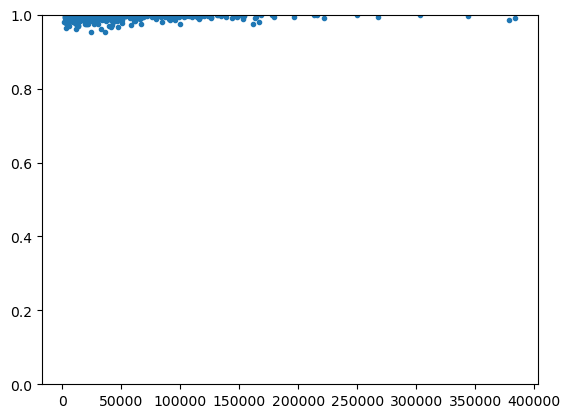

In [71]:
plt.plot(pFN.var(axis=1), r_s, '.')
plt.ylim([0, 1])

In [10]:
# Make MF positive beta, PC beta negative

for type in range(3):
    # Set up the design matrix pMPC
    if type == 0:
        # Concatenated case: [PC, MF]
        pMPC = np.hstack([pPC.T, pMF.T])
    elif type == 1:
        # PC only case
        pMPC = pPC.T
    else:  # type == 2
        # MF only case
        pMPC = pMF.T

    # Perform NNLS for each target
    betas_pn = []
    r_2_pn = []
    resid_t = []
    for a in range(len(pFN)):
        beta, resid = optimize.nnls(pMPC, pFN[a])
        resid2 = resid**2
        r_s = 1 - resid2 / (pFN[a].size * pFN[a].var())
        betas_pn.append(beta)
        r_2_pn.append(r_s)
        resid_t.append(resid)

    # Convert lists to arrays and adjust signs
    if type == 0:
        # Concatenated case: multiply PC components by -1
        betas_pn1 = np.array(betas_pn)
        betas_pn1[:, :pPC.shape[0]] *= -1  # Make PC components negative
        r_2_pn1 = np.array(r_2_pn)
        resid_t1 = np.array(resid_t)
    elif type == 1:
        # PC only case: multiply all by -1
        betas_pn3 = np.array(betas_pn) * -1  # Make all components negative
        r_2_pn3 = np.array(r_2_pn)
        resid_t3 = np.array(resid_t)
    else: 
        # MF only case: keep positive
        betas_pn2 = np.array(betas_pn)  # Keep all components positive
        r_2_pn2 = np.array(r_2_pn)
        resid_t2 = np.array(resid_t)

In [125]:
print(f"PCMF -> FN: {np.mean(r_2_pn1)}")
print(f"PC -> FN: {np.mean(r_2_pn3)}")
print(f"MF -> FN: {np.mean(r_2_pn2)}")

PCMF -> FN: 0.9530828192742855
PC -> FN: 0.9148824500299082
MF -> FN: 0.4644637757454279


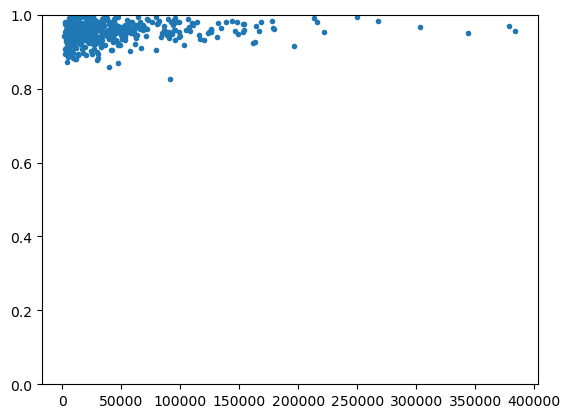

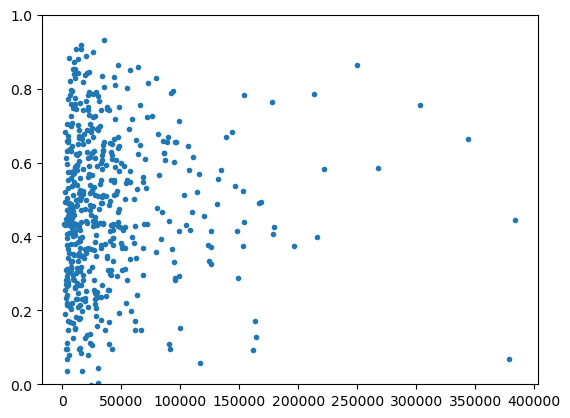

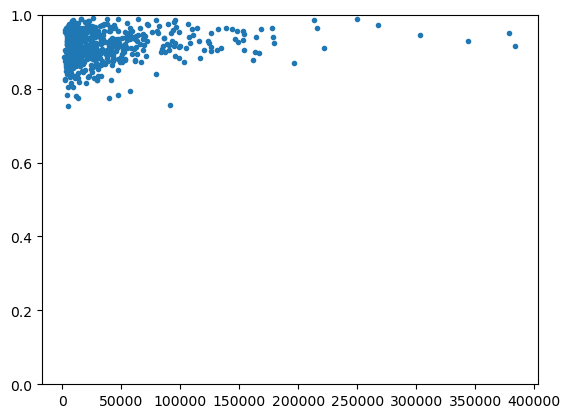

In [126]:
# PCMF
plt.plot(pFN.var(axis=1), r_2_pn1, '.')
plt.ylim([0, 1])
plt.show()

# MF
plt.plot(pFN.var(axis=1), r_2_pn2, '.')
plt.ylim([0, 1])
plt.show()

# PC
plt.plot(pFN.var(axis=1), r_2_pn3, '.')
plt.ylim([0, 1])
plt.show()

In [ ]:
# Make MF positive beta , PC beta negative

for type in range(3):

    if type == 1:
        pMPC = pPC.T
    elif type == 2:
        pMPC = pMF.T

    betas_pn = []
    r_2_pn = []
    resid_t = []
    for a in range(len(pFN)):
        beta, resid = optimize.nnls(pMPC, pFN[a])
        resid2 = resid **2
        r_s = 1 - resid2 / (pFN[a].size * pFN[a].var())
        betas_pn.append(beta)
        r_2_pn.append(r_s)
        resid_t.append(resid)

    if pMPC.shape[1] == pMF.shape[0]:
        betas_pn2 = np.array(betas_pn)
        r_2_pn2 = np.array(r_2_pn)
        resid_t2 = np.array(resid_t)
    elif pMPC.shape[1] == pPC.shape[0]:
        betas_pn3 = np.array(betas_pn) * -1
        r_2_pn3 = np.array(r_2_pn)
        resid_t3 = np.array(resid_t)
    else:
        betas_pn1 = np.array(betas_pn)
        # betas_pn1[:, :pPC.shape[0]] = betas_pn1[:, :pPC.shape[0]] * -1
        r_2_pn1 = np.array(r_2_pn)
        resid_t1 = np.array(resid_t)

betas_pn1[:, :pPC.shape[0]] = betas_pn1[:, :pPC.shape[0]] * -1

ValueError: Expected a one-dimensional array (vector), but the shape of b is (500, 67)

In [ ]:
# Make MF positive beta , PC beta negative
# pMPC = pPC.T

if pMPC.shape[1] == pMP.shape[0]:
    lower_bounds = np.zeros(pMP.shape[0])
    upper_bounds = np.tile(np.inf, pMP.shape[0])
elif pMPC.shape[1] == pPC.shape[0]:
    lower_bounds = np.tile(-np.inf, pPC.shape[0])
    upper_bounds = np.zeros(pPC.shape[0])
else:
    lower_bounds = np.concatenate([np.tile(-np.inf, pPC.shape[0]), np.zeros(pMP.shape[0])])
    upper_bounds = np.concatenate([np.zeros(pPC.shape[0]), np.tile(np.inf, pMP.shape[0])])

betas_pn = []
r_2_pn = []
resid_t = []
for a in range(len(pFN)):
    pFN[a] = pFN[a] - np.mean(pFN[a][:100])
    # pFN[a] = pFN[a] - np.mean(pFN[a])
    output = optimize.lsq_linear(pMPC, pFN[a], bounds=(lower_bounds, upper_bounds), max_iter = 400)
    beta = output['x']; temp_var = output['fun'] - np.mean(output['fun'])
    # resid = np.linalg.norm(output['fun']) ** 2
    resid = np.linalg.norm(temp_var) ** 2

    r_s = 1 - resid / (pFN[a].size * pFN[a].var())
    betas_pn.append(beta)
    r_2_pn.append(r_s)
    resid_t.append(resid)

if pMPC.shape[1] == pMP.shape[0]:
    betas_pn2 = np.array(betas_pn)
    r_2_pn2 = np.array(r_2_pn)
    resid_t2 = np.array(resid_t)
elif pMPC.shape[1] == pPC.shape[0]:
    betas_pn3 = np.array(betas_pn)
    r_2_pn3 = np.array(r_2_pn)
    resid_t3 = np.array(resid_t)
else:
    betas_pn1 = np.array(betas_pn)
    r_2_pn1 = np.array(r_2_pn)
    resid_t1 = np.array(resid_t)

(0.0, 1.0)

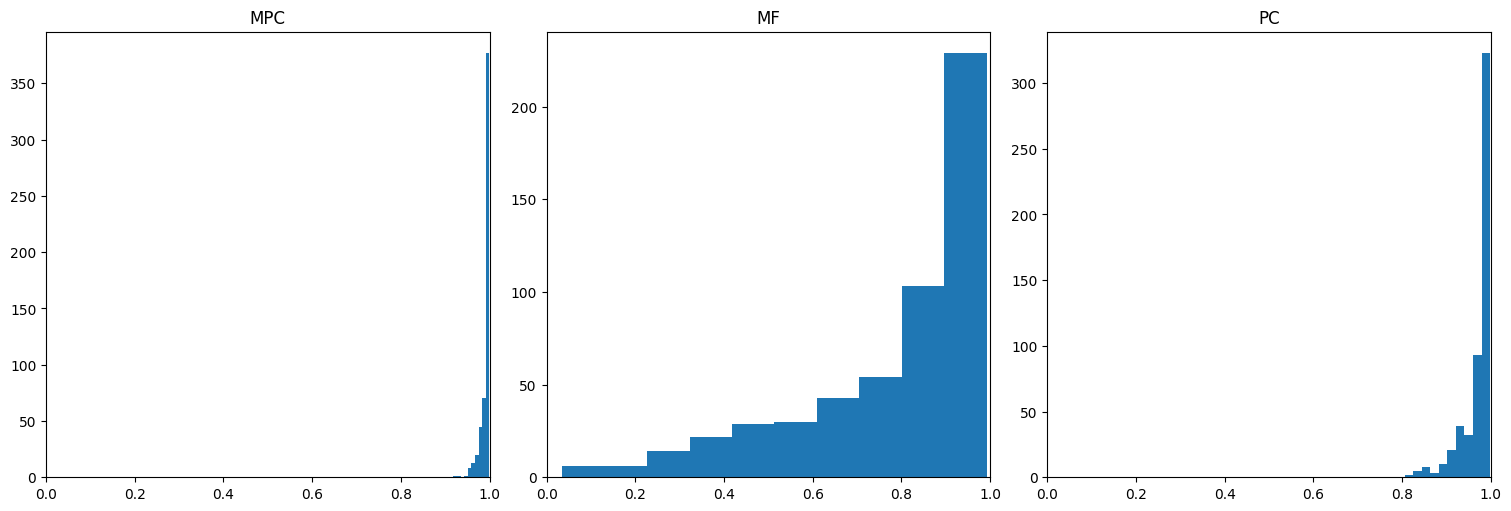

In [ ]:
fig = plt.figure(constrained_layout=True,figsize=(15,5))

ax = fig.add_subplot(1, 3, 1)
ax.hist(r_2_pn1)
ax.set_title('MPC')
ax.set_xlim(0, 1)
ax = fig.add_subplot(1, 3, 2)
ax.hist(r_2_pn2)
ax.set_title('MF')
ax.set_xlim(0, 1)
ax = fig.add_subplot(1, 3, 3)
ax.hist(r_2_pn3)
ax.set_title('PC')
ax.set_xlim(0, 1)

In [593]:
mr1 = round(np.mean(r_2_pn1), 2)
mr2 = round(np.mean(r_2_pn2), 2)
mr3 = round(np.mean(r_2_pn3), 2)

stdr1 = round(np.std(r_2_pn1), 2)
stdr2 = round(np.std(r_2_pn2), 2)
stdr3 = round(np.std(r_2_pn3), 2)

Text(0, 0.5, 'R^2')

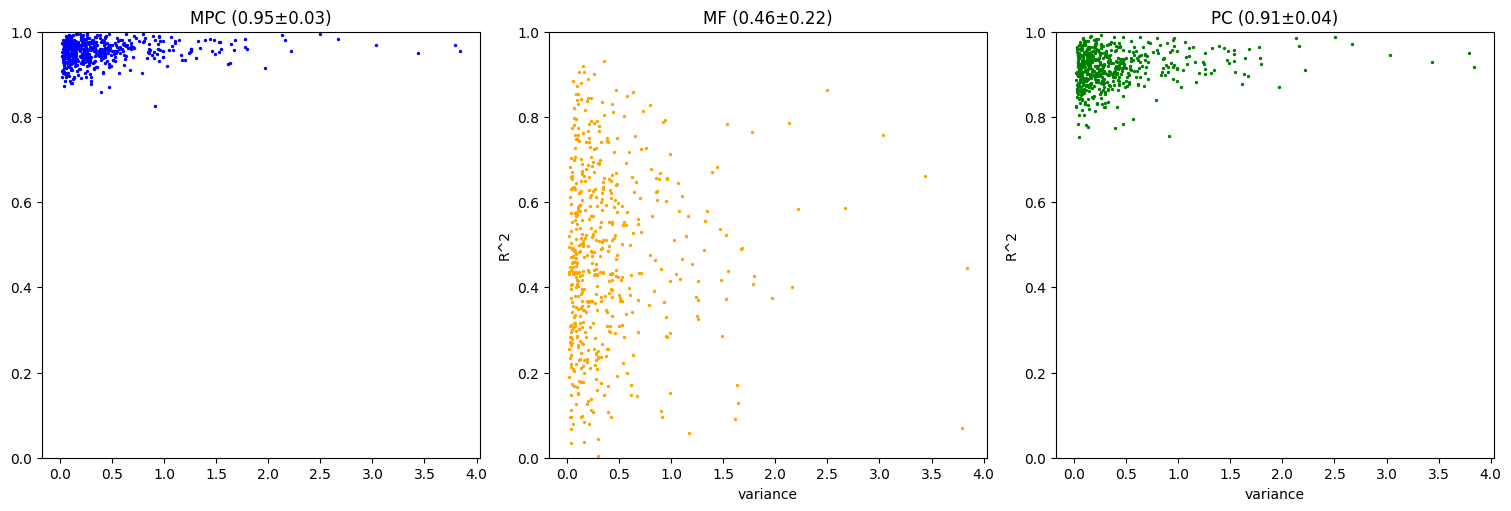

In [597]:
fig = plt.figure(constrained_layout=True,figsize=(15,5))

ax = fig.add_subplot(1, 3, 1)
ax.scatter(pFN.var(axis=1)*1e-5, r_2_pn1, 2,'b')
ax.set_title(f'MPC ({mr1}\u00B1{stdr1})')
ax.set_ylim(0, 1)

ax = fig.add_subplot(1, 3, 2)
ax.scatter(pFN.var(axis=1)*1e-5, r_2_pn2, 2, 'orange')
ax.set_title(f'MF ({mr2}\u00B1{stdr2})')
ax.set_ylim(0, 1)
ax.set_xlabel("variance")
ax.set_ylabel("R^2")

ax = fig.add_subplot(1, 3, 3)
ax.scatter(pFN.var(axis=1)*1e-5, r_2_pn3, 2, 'g')
ax.set_title(f'PC ({mr3}\u00B1{stdr3})')
ax.set_ylim(0, 1)
ax.set_xlabel("variance")
ax.set_ylabel("R^2")

TypeError: 'Axes' object is not subscriptable

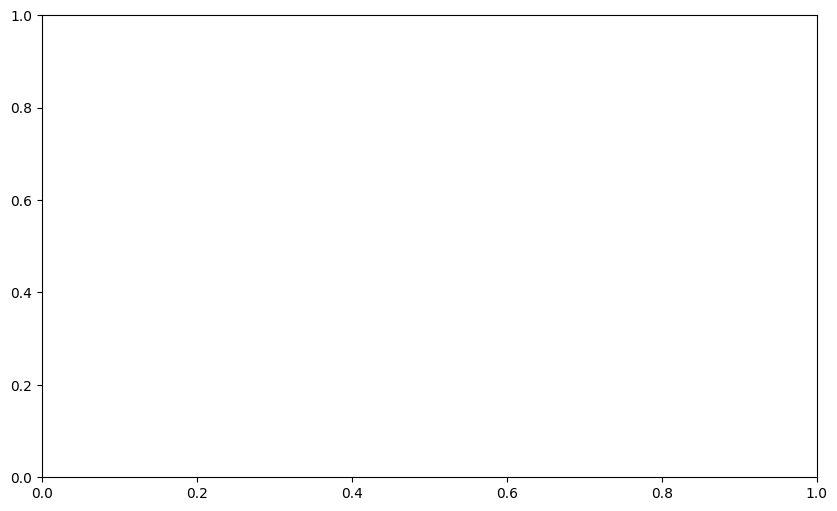

In [623]:
fig, axes = plt.subplots(figsize = (10, 6))

axes[1].scatter(pFN.var(axis=1)*1e-5, r_2_pn2, 2, 'orange')
axes[1].set_title(f'MF ({mr2}\u00B1{stdr2})')
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("variance")
axes[1].set_ylabel("R^2")

axes[2].scatter(pFN.var(axis=1)*1e-5, r_2_pn3, 2, 'g')
axes[2].set_title(f'PC ({mr3}\u00B1{stdr3})')
axes[2].set_ylim(0, 1)
axes[2].set_xlabel("variance")
axes[2].set_ylabel("R^2")

plt.tight_layout()

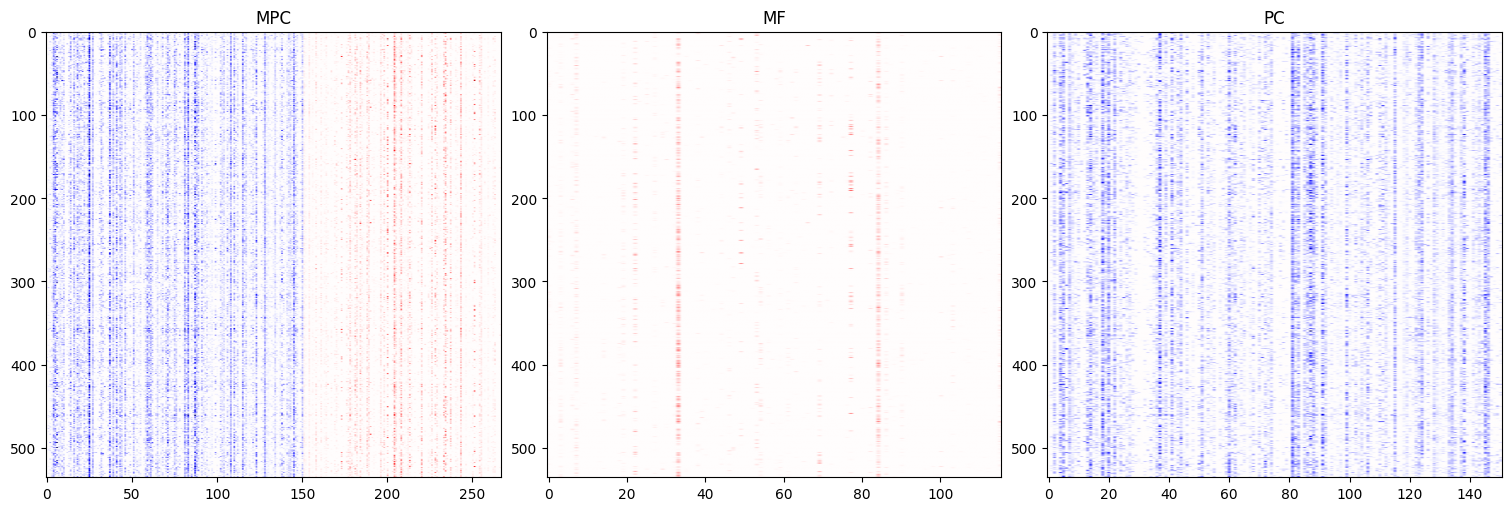

In [148]:
fig = plt.figure(constrained_layout=True,figsize=(15,5))

ax1 = fig.add_subplot(1, 3, 1)
fig1 = ax1.imshow(betas_pn1, aspect='auto', cmap='seismic', origin='upper')
ax1.set_title('MPC')
fig1.set_clim(-10, 10)

ax2 = fig.add_subplot(1, 3, 2)
fig2 = ax2.imshow(betas_pn2, aspect='auto', cmap='seismic', origin='upper')
ax2.set_title('MF')
fig2.set_clim(-10, 10)

ax3 = fig.add_subplot(1, 3, 3)
fig3 = ax3.imshow(betas_pn3, aspect='auto', cmap='seismic', origin='upper')
ax3.set_title('PC')
fig3.set_clim(-10, 10)


# plt.colorbar()

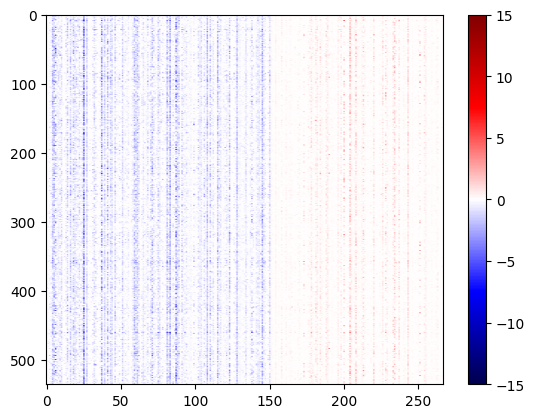

In [149]:
plt.imshow(betas_pn1, aspect='auto', cmap='seismic', origin='upper')
plt.clim(-15, 15)
plt.colorbar()

0.0
-1.1102230246251565e-16
0.024553368797591808
0.027298979996071084
0.027298979996071084


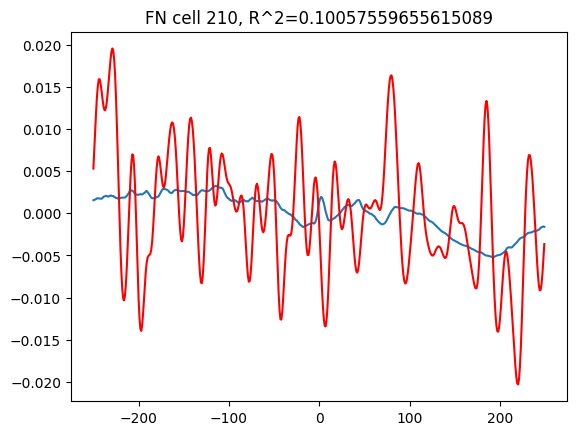

In [21]:
# plotting
t = np.arange(-250,250)

a=209
plt.plot(t, pMPC @ betas_pn[a])
plt.plot(t, pFN[a], 'r')
plt.title(f'FN cell {a+1}, R^2={r_2_pn[a]}')
print(np.mean(pMPC @ betas_pn[a]) * 500)
print(np.mean(pFN[a]) * 500)
print(np.sum((pMPC @ betas_pn[a] - pFN[a]) ** 2))
print(pFN[a].size * pFN[a].var())
print(np.sum((pFN[a] - np.mean(pFN[a])) ** 2))

In [22]:
np.argsort(r_2_pn)

array([360, 209, 245, 276, 293,  94, 295,  19, 161, 483,  89,  73,  27,
       159, 172, 429, 214, 496, 353, 228, 427, 482, 226, 311, 281, 147,
       140, 416, 425, 445, 168, 358, 349, 223,  97, 235, 494,  86, 527,
       286, 219,  22, 432, 357,  80, 365, 164,  30, 207,  18, 362, 369,
       290, 190, 141,  92, 499,  25, 488, 156, 178, 341, 101,  24, 475,
       348, 446, 436, 492, 420, 205,  13, 274, 491, 169, 298, 343, 148,
        75, 418, 531, 302, 434, 415, 367, 408, 152, 291,  91, 105, 233,
       312, 243, 495,  23, 423,  58, 378, 244, 300, 157, 229, 142, 493,
       406, 153,  14, 176, 231, 487, 410, 426, 485, 215, 220,  62,   8,
         6, 513,  81,  85, 239, 162, 282, 512, 421, 469, 379, 287,  21,
       490,  43, 257, 177, 160,   0, 473,   4, 477,  95, 288, 224, 424,
        67, 461,  90,  42,  34, 402,  87, 465, 476, 470, 110, 351, 409,
       299, 165,   1,  71, 125, 306, 221, 366,  63, 503, 238, 166, 507,
       294, 232, 227, 347, 440, 411, 433, 154, 138, 428, 404, 11

In [64]:
pc_tensor.shape, mf_tensor.shape

(torch.Size([151, 500]), torch.Size([116, 500]))

In [778]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import r2_score


pc_tensor = torch.tensor(pPC, dtype=torch.float32).T
mf_tensor = torch.tensor(pMF, dtype=torch.float32).T
fn_tensor = torch.tensor(pFN, dtype=torch.float32).T

pc_d = pc_tensor.shape[1] 
mf_d = mf_tensor.shape[1]  
fn_d = fn_tensor.shape[1]

pc_mean = pc_tensor.mean(axis=0)
pc_std = pc_tensor.std(axis=0)
pc_nor = (pc_tensor - pc_mean) / (pc_std + 1e-8)

mf_mean = mf_tensor.mean(axis=0)
mf_std = mf_tensor.std(axis=0)
mf_nor = (mf_tensor - mf_mean) / (mf_std + 1e-8)

fn_mean = fn_tensor.mean(axis=0)
fn_std = fn_tensor.std(axis=0)
fn_nor = (fn_tensor - fn_mean) / (fn_std + 1e-8)


class PC_MF_to_FN_Model(nn.Module):
    def __init__(self, pc_dim, mf_dim, fn_dim):
        super(PC_MF_to_FN_Model, self).__init__()
        
        self.pc_branch = nn.Sequential(
            nn.Linear(pc_dim, 64),
            nn.Linear(64, 32),
            nn.Linear(32, fn_dim)
        )
        
        self.mf_branch = nn.Sequential(
            nn.Linear(mf_dim, 64),
            nn.Linear(64, 32),
            nn.Linear(32, fn_dim)
        )

    def forward(self, pc_input, mf_input):

        pc_output = -1 * (self.pc_branch(pc_input)) # PC < 0
        
        mf_output = (self.mf_branch(mf_input)) # MF > 0

        fn_pred = pc_output + mf_output
        
        return fn_pred, pc_output, mf_output


model = PC_MF_to_FN_Model(pc_d, mf_d, fn_d)

loss_list = []
r2_list = []
learning_rate = 0.01

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

epochs = 500
for epoch in range(epochs):
    model.train()
    
    fn_pred, _, _ = model(pc_nor, mf_nor)
    
    loss = criterion(fn_pred, fn_nor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():}')

    loss_list.append(loss.item())

    with torch.no_grad():
        r2 = r2_score(fn_nor.numpy(), fn_pred.numpy())
        r2_list.append(r2)


model.eval()
with torch.no_grad():
    fn_predicted, pc_predicted, mf_predicted = model(pc_nor, mf_nor)

    fn_arr = fn_nor.numpy()
    fn_predicted = fn_predicted.numpy()

    r2_nn = r2_score(fn_arr, fn_predicted)
print(f"R^2: {r2_nn}")

Epoch [1/500], Loss: 1.0921748876571655
Epoch [2/500], Loss: 1.0669540166854858
Epoch [3/500], Loss: 0.9354422092437744
Epoch [4/500], Loss: 0.847566545009613
Epoch [5/500], Loss: 0.7765354514122009
Epoch [6/500], Loss: 0.7150106430053711
Epoch [7/500], Loss: 0.6658292412757874
Epoch [8/500], Loss: 0.6222971677780151
Epoch [9/500], Loss: 0.5872762203216553
Epoch [10/500], Loss: 0.55986487865448
Epoch [11/500], Loss: 0.534389078617096
Epoch [12/500], Loss: 0.5109400153160095
Epoch [13/500], Loss: 0.4897363483905792
Epoch [14/500], Loss: 0.47163626551628113
Epoch [15/500], Loss: 0.45747247338294983
Epoch [16/500], Loss: 0.4435235261917114
Epoch [17/500], Loss: 0.4216015338897705
Epoch [18/500], Loss: 0.4040580093860626
Epoch [19/500], Loss: 0.39474037289619446
Epoch [20/500], Loss: 0.37683621048927307
Epoch [21/500], Loss: 0.3634037673473358
Epoch [22/500], Loss: 0.351650208234787
Epoch [23/500], Loss: 0.3361581563949585
Epoch [24/500], Loss: 0.32561182975769043
Epoch [25/500], Loss: 0.3

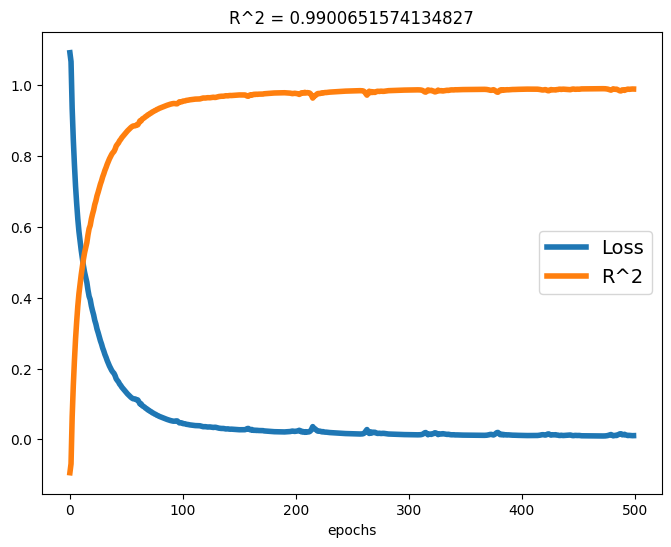

In [779]:
fig = plt.subplots(figsize = (8, 6))

plt.plot(np.array(loss_list), linewidth = 4, label = "Loss");

plt.plot(r2_list, linewidth = 4, label = "R^2");
plt.title(f'R^2 = {r2_nn}')
plt.xlabel("epochs")

plt.legend(fontsize = 14)

# plt.tight_layout()
plt.savefig("r2loss_function.pdf", dpi = 600)

plt.show()

In [760]:
class PC_to_FN_Model(nn.Module):
    def __init__(self, pc_dim, fn_dim):
        super(PC_to_FN_Model, self).__init__()
        
        self.pc_branch = nn.Sequential(
            nn.Linear(pc_dim, 64),
            nn.Linear(64, 32),
            nn.Linear(32, fn_dim)
        )

    def forward(self, pc_input):

        pc_output = -1 * (self.pc_branch(pc_input)) # PC < 0
        
        fn_pred = pc_output 
        
        return fn_pred, pc_output


model = PC_to_FN_Model(pc_d, fn_d)

loss_list = []
r2_list = []
learning_rate = 0.01

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

epochs = 500
for epoch in range(epochs):
    model.train()
    
    fn_pred, _ = model(pc_nor)
    
    loss = criterion(fn_pred, fn_nor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():}')

    loss_list.append(loss.item())

    with torch.no_grad():
        r2 = r2_score(fn_nor.numpy(), fn_pred.numpy())
        r2_list.append(r2)


model.eval()
with torch.no_grad():
    fn_predicted, pc_predicted = model(pc_nor)

    fn_arr = fn_nor.numpy()
    fn_predicted = fn_predicted.numpy()

    r2_nn = r2_score(fn_arr, fn_predicted)
print(f"R^2: {r2_nn}")

Epoch [1/500], Loss: 1.041271448135376
Epoch [2/500], Loss: 1.0288634300231934
Epoch [3/500], Loss: 0.9612335562705994
Epoch [4/500], Loss: 0.9109623432159424
Epoch [5/500], Loss: 0.8548464775085449
Epoch [6/500], Loss: 0.7981411218643188
Epoch [7/500], Loss: 0.7433028221130371
Epoch [8/500], Loss: 0.6913076639175415
Epoch [9/500], Loss: 0.6494690775871277
Epoch [10/500], Loss: 0.6158207058906555
Epoch [11/500], Loss: 0.5869207382202148
Epoch [12/500], Loss: 0.5623489022254944
Epoch [13/500], Loss: 0.5404986143112183
Epoch [14/500], Loss: 0.5218765139579773
Epoch [15/500], Loss: 0.5046116709709167
Epoch [16/500], Loss: 0.4883061647415161
Epoch [17/500], Loss: 0.473436564207077
Epoch [18/500], Loss: 0.4586814045906067
Epoch [19/500], Loss: 0.44095316529273987
Epoch [20/500], Loss: 0.42407917976379395
Epoch [21/500], Loss: 0.41208675503730774
Epoch [22/500], Loss: 0.39780423045158386
Epoch [23/500], Loss: 0.3825564682483673
Epoch [24/500], Loss: 0.3720310926437378
Epoch [25/500], Loss: 0

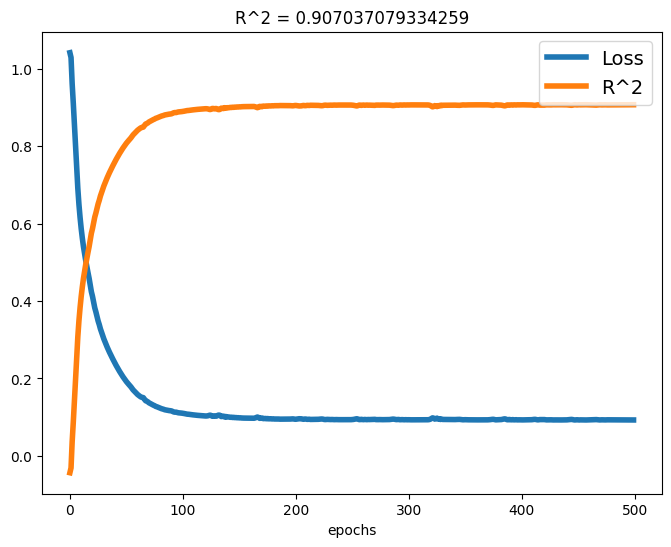

In [761]:
fig = plt.subplots(figsize = (8, 6))

plt.plot(np.array(loss_list), linewidth = 4, label = "Loss");

plt.plot(r2_list, linewidth = 4, label = "R^2");
plt.title(f'R^2 = {r2_nn}')
plt.xlabel("epochs")

plt.legend(fontsize = 14)

# plt.tight_layout()
plt.savefig("r2loss_function_onlyPC.pdf", dpi = 600)

plt.show()

In [771]:
class MF_to_FN_Model(nn.Module):
    def __init__(self, mf_dim, fn_dim):
        super(MF_to_FN_Model, self).__init__()
        
        self.mf_branch = nn.Sequential(
            nn.Linear(mf_dim, 64),
            nn.Linear(64, 32),
            nn.Linear(32, fn_dim)
        )

    def forward(self, mf_input):

        mf_output = (self.mf_branch(mf_input))
        
        fn_pred = mf_output 
        
        return fn_pred, mf_output


model = MF_to_FN_Model(mf_d, fn_d)

loss_list = []
r2_list = []
learning_rate = 0.01

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

epochs = 500
for epoch in range(epochs):
    model.train()
    
    fn_pred, _ = model(mf_nor)
    
    loss = criterion(fn_pred, fn_nor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():}')

    loss_list.append(loss.item())

    with torch.no_grad():
        r2 = r2_score(fn_nor.numpy(), fn_pred.numpy())
        r2_list.append(r2)


model.eval()
with torch.no_grad():
    fn_predicted, mf_predicted = model(mf_nor)

    fn_arr = fn_nor.numpy()
    fn_predicted = fn_predicted.numpy()

    r2_nn = r2_score(fn_arr, fn_predicted)
print(f"R^2: {r2_nn}")

Epoch [1/500], Loss: 1.0468543767929077
Epoch [2/500], Loss: 1.046775221824646
Epoch [3/500], Loss: 0.9830089807510376
Epoch [4/500], Loss: 0.9435403347015381
Epoch [5/500], Loss: 0.8923313021659851
Epoch [6/500], Loss: 0.8458156585693359
Epoch [7/500], Loss: 0.8041947484016418
Epoch [8/500], Loss: 0.7615306377410889
Epoch [9/500], Loss: 0.7221329212188721
Epoch [10/500], Loss: 0.6917762160301208
Epoch [11/500], Loss: 0.667281985282898
Epoch [12/500], Loss: 0.6460976600646973
Epoch [13/500], Loss: 0.6262361407279968
Epoch [14/500], Loss: 0.6085676550865173
Epoch [15/500], Loss: 0.5931501984596252
Epoch [16/500], Loss: 0.5801808834075928
Epoch [17/500], Loss: 0.5696240663528442
Epoch [18/500], Loss: 0.5578740835189819
Epoch [19/500], Loss: 0.5456847548484802
Epoch [20/500], Loss: 0.5355794429779053
Epoch [21/500], Loss: 0.526378333568573
Epoch [22/500], Loss: 0.5161780714988708
Epoch [23/500], Loss: 0.5067929029464722
Epoch [24/500], Loss: 0.4986516535282135
Epoch [25/500], Loss: 0.4894

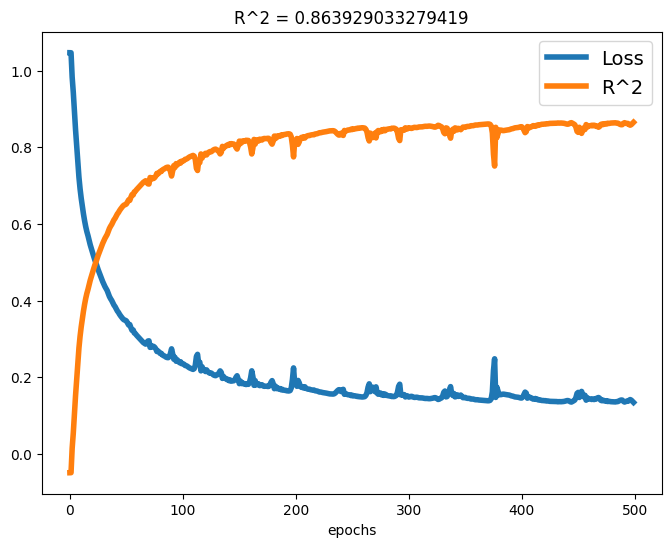

In [772]:
fig = plt.subplots(figsize = (8, 6))

plt.plot(np.array(loss_list), linewidth = 4, label = "Loss");

plt.plot(r2_list, linewidth = 4, label = "R^2");
plt.title(f'R^2 = {r2_nn}')
plt.xlabel("epochs")

plt.legend(fontsize = 14)

# plt.tight_layout()
plt.savefig("r2loss_function_onlyMF.pdf", dpi = 600)

plt.show()

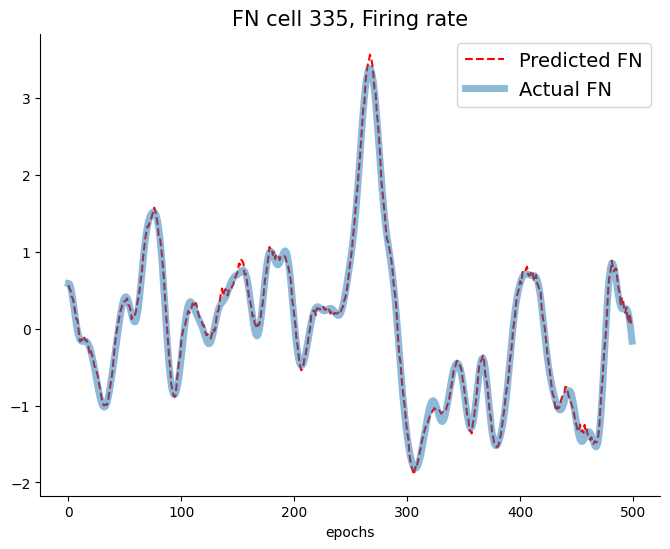

In [591]:
fig, ax = plt.subplots(figsize = (8, 6))

plt.plot(fn_predicted[:, 335], 'r--', label = "Predicted FN");
plt.plot(fn_nor[:, 335], alpha = 0.5, linewidth = 5, label = "Actual FN");

plt.xlabel("epochs")
plt.title("FN cell 335, Firing rate", fontsize = 15)
plt.legend(fontsize = 14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.savefig("pred_NN.pdf", dpi = 600)

plt.show()

In [570]:
fn_predicted[:, 335], fn_predicted[:, 0]

(array([ 5.66375971e-01,  5.22060156e-01,  4.96128798e-01,  4.12927985e-01,
         3.93537521e-01,  3.12863708e-01,  2.15905428e-01,  1.24302149e-01,
         1.18127942e-01, -9.57834721e-03, -1.56320930e-01, -1.62060261e-01,
        -1.34110928e-01, -1.56622052e-01, -1.14180565e-01, -1.52549148e-01,
        -1.45563006e-01, -1.84419990e-01, -2.57281780e-01, -3.37506413e-01,
        -2.93466210e-01, -3.48483205e-01, -4.06391621e-01, -4.83003378e-01,
        -5.11178017e-01, -5.63431025e-01, -6.12993121e-01, -7.06934333e-01,
        -7.81866431e-01, -8.75254035e-01, -9.33517933e-01, -9.91568089e-01,
        -9.96283412e-01, -9.85168219e-01, -9.91916060e-01, -9.59122658e-01,
        -8.42192888e-01, -7.52590418e-01, -6.58315778e-01, -5.60662746e-01,
        -3.85952592e-01, -2.34580398e-01, -1.03766799e-01, -1.14879608e-02,
         6.80375099e-02,  1.42175078e-01,  2.21347690e-01,  2.70873904e-01,
         3.39113355e-01,  3.54322314e-01,  3.56342912e-01,  3.71259928e-01,
         3.9

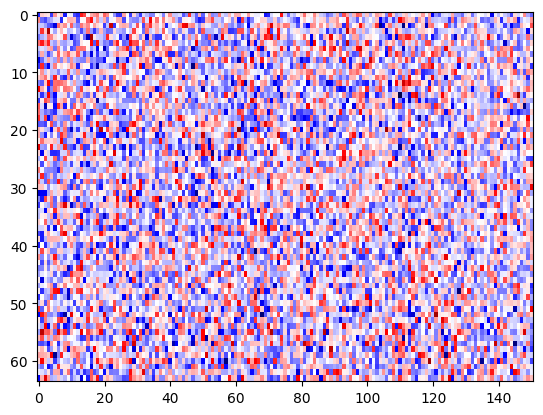

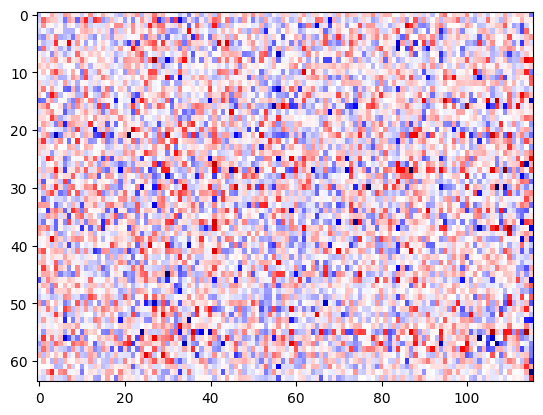

In [436]:
pc_weights = model.pc_branch[0].weight.data.numpy()*1e2
mf_weights = model.mf_branch[0].weight.data.numpy()*1e2

plt.imshow(pc_weights, cmap='seismic', aspect='auto')
plt.show()

plt.imshow(mf_weights, cmap='seismic', aspect='auto')
plt.show()

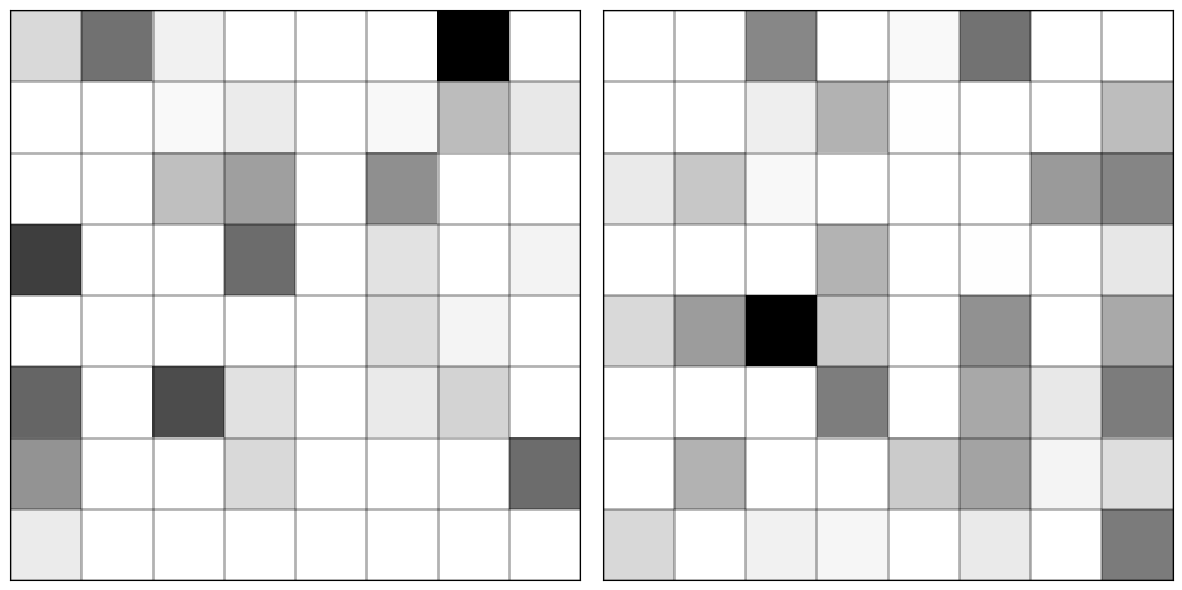

In [624]:
plt.figure(figsize=(12, 6))

ax1 = plt.subplot(1, 2, 1)
pc_activation_map = activations[model.pc_branch[1]].squeeze().numpy()
im1 = ax1.imshow(pc_activation_map.reshape(8, 8), cmap='gray_r', interpolation='nearest')

ax1.set_xticks(np.arange(-0.5, 8, 1))
ax1.set_yticks(np.arange(-0.5, 8, 1))
ax1.set_xticklabels([])
ax1.set_yticklabels([])
ax1.tick_params(length=0)
ax1.grid(which='both', color='black', linestyle='-', linewidth=2, alpha = 0.3)

ax2 = plt.subplot(1, 2, 2)
mf_activation_map = activations[model.mf_branch[1]].squeeze().numpy()
im2 = ax2.imshow(mf_activation_map.reshape(8, 8), cmap='gray_r', interpolation='nearest')

ax2.set_xticks(np.arange(-0.5, 8, 1))
ax2.set_yticks(np.arange(-0.5, 8, 1))
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.tick_params(length=0)
ax2.grid(which='both', color='black', linestyle='-', linewidth=2, alpha = 0.3)

plt.tight_layout()
plt.savefig("activationmap_with_grid.pdf", dpi = 600)
plt.show()

## Create Neural Network Model with communication space
PC -> (communication space) -> FN

In [900]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import numpy as np
from tqdm import tqdm
from sklearn.metrics import r2_score

pc_tensor = torch.tensor(pPC, dtype=torch.float32).T
fn_tensor = torch.tensor(pFN, dtype=torch.float32).T

pc_d = pc_tensor.shape[1] 
fn_d = fn_tensor.shape[1]

pc_mean = pc_tensor.mean(axis=0)
pc_std = pc_tensor.std(axis=0)
pc_nor = (pc_tensor - pc_mean) / (pc_std + 1e-8)

fn_mean = fn_tensor.mean(axis=0)
fn_std = fn_tensor.std(axis=0)
fn_nor = (fn_tensor - fn_mean) / (fn_std + 1e-8)

X_train, X_test, y_train, y_test = train_test_split(pc_nor, fn_nor, test_size=0.2, random_state=42)


In [913]:
class PCtoFN_subspace(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(PCtoFN_subspace, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, hidden_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, output_dim)
        )
    def forward(self, x):
        communication_space = self.encoder(x)
        output = self.decoder(communication_space)
        return output

communication_space_dims = range(1, 11)
losses = []
r_squareds = []
learning_rate = 0.01

for dim in tqdm(communication_space_dims, desc="----"):
    model = PCtoFN_subspace(input_dim=pc_d, hidden_dim=dim, output_dim=fn_d)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

    for epoch in range(500):
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        model.eval()
        test_outputs = model(X_test)
        loss = criterion(test_outputs, y_test).item()
        r2 = r2_score(y_test.numpy(), test_outputs.numpy())
        
    losses.append(loss)
    r_squareds.append(r2)
    print(f"Dimension: {dim}, Loss: {loss:.4f}, R-squared: {r2:.4f}")


----:  10%|█         | 1/10 [00:00<00:05,  1.54it/s]

Dimension: 1, Loss: 0.8666, R-squared: 0.0720


----:  20%|██        | 2/10 [00:01<00:05,  1.49it/s]

Dimension: 2, Loss: 0.6716, R-squared: 0.2823


----:  30%|███       | 3/10 [00:02<00:04,  1.43it/s]

...

Dimension: 8, Loss: 0.3810, R-squared: 0.5943


----:  90%|█████████ | 9/10 [00:06<00:00,  1.39it/s]

Dimension: 9, Loss: 0.3421, R-squared: 0.6353


----: 100%|██████████| 10/10 [00:07<00:00,  1.40it/s]

Dimension: 10, Loss: 0.3116, R-squared: 0.6678


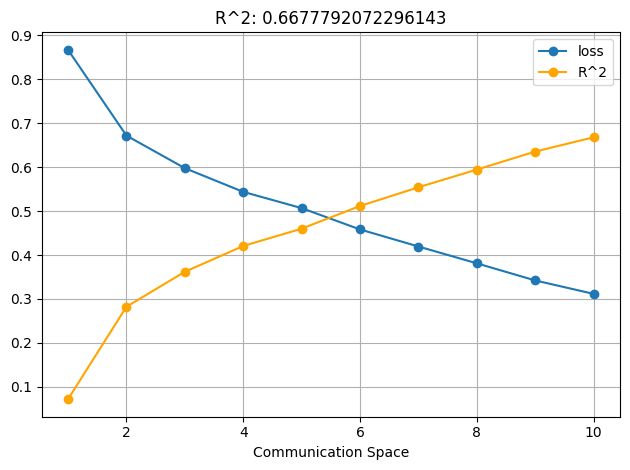

In [917]:
plt.plot(communication_space_dims, losses, marker='o', label = 'loss')

plt.plot(communication_space_dims, r_squareds, marker='o', color='orange', label = 'R^2')

plt.title(f'R^2: {r2}')
plt.xlabel('Communication Space')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

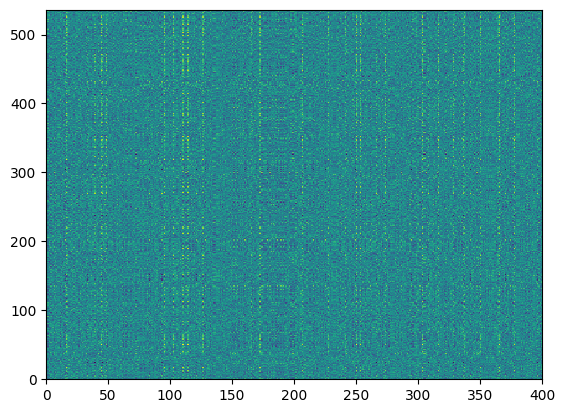

In [925]:
plt.pcolormesh(outputs.detach().numpy().T, cmap='viridis');

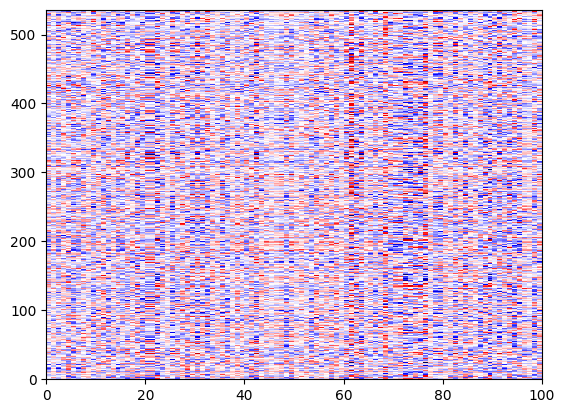

In [929]:
plt.pcolormesh(test_outputs.detach().numpy().T, cmap='seismic');